# 01 — Data Generation & Schema Understanding

## Objective
Understand the structure, shape, and quality of the raw data we generated
that simulates a Bangalore ride sharing platform (Ola/Uber/Rapido style).

## What This Notebook Covers
- Schema of each table
- Row counts and column types
- Null value analysis per table
- Duplicate detection
- Outlier identification
- Key observations before we touch any cleaning

## Data Period : Full Year 2025
## City        : Bangalore
## Tables      : rides, drivers, users, payments, weather

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
DATA_PATH = "../data/raw/"

rides_df    = pd.read_csv(DATA_PATH + "rides.csv")
drivers_df  = pd.read_csv(DATA_PATH + "drivers.csv")
users_df    = pd.read_csv(DATA_PATH + "users.csv")
payments_df = pd.read_csv(DATA_PATH + "payments.csv")
weather_df  = pd.read_csv(DATA_PATH + "weather.csv")

print("All tables loaded ✅")
print(f"  rides    : {rides_df.shape}")
print(f"  drivers  : {drivers_df.shape}")
print(f"  users    : {users_df.shape}")
print(f"  payments : {payments_df.shape}")
print(f"  weather  : {weather_df.shape}")

All tables loaded ✅
  rides    : (50250, 25)
  drivers  : (3000, 16)
  users    : (20200, 13)
  payments : (39191, 8)
  weather  : (87600, 7)


## Table Relationships

In [3]:
tables = {
    "rides"   : rides_df,
    "drivers" : drivers_df,
    "users"   : users_df,
    "payments": payments_df,
    "weather" : weather_df,
}

for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f" TABLE: {name.upper()}  |  {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*55}")
    print(df.dtypes.to_string())


 TABLE: RIDES  |  50,250 rows × 25 columns
ride_id                    str
driver_id                  str
user_id                    str
pickup_zone                str
drop_zone                  str
pickup_lat             float64
pickup_lon             float64
drop_lat               float64
drop_lon               float64
vehicle_type               str
ride_timestamp             str
hour                     int64
month                    int64
day_of_week                str
is_weekend                bool
is_holiday                bool
weather_condition          str
distance_km            float64
duration_min           float64
base_fare                int64
fare_amount            float64
surge_multiplier       float64
ride_status                str
cancellation_reason        str
driver_rating_given    float64

 TABLE: DRIVERS  |  3,000 rows × 16 columns
driver_id                   str
name                        str
phone                   float64
home_zone                   str
vehicle_

In [4]:
print("\n NULL VALUE SUMMARY PER TABLE\n")

for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    null_pct    = (null_counts / len(df) * 100).round(2)

    print(f"\n── {name.upper()} ──")
    if len(null_counts) == 0:
        print("  No nulls found")
    else:
        summary = pd.DataFrame({
            "null_count" : null_counts,
            "null_%"     : null_pct
        })
        print(summary.to_string())


 NULL VALUE SUMMARY PER TABLE


── RIDES ──
                     null_count  null_%
pickup_zone                1519    3.02
drop_zone                   998    1.99
duration_min              11059   22.01
fare_amount                 785    1.56
cancellation_reason       42853   85.28
driver_rating_given       20774   41.34

── DRIVERS ──
                      null_count  null_%
phone                         62    2.07
vehicle_model                224    7.47
vehicle_year                 343   11.43
rating                        94    3.13
acceptance_rate              128    4.27
online_hours_per_day         147    4.90

── USERS ──
                 null_count  null_%
phone                   695    3.44
email                  1030    5.10
gender                 5127   25.38
rating                  814    4.03
is_prime_member        6707   33.20

── PAYMENTS ──
                null_count  null_%
amount                 609    1.55
tip                   3114    7.95
transaction_id       11

In [5]:
print("\n DUPLICATE ROW DETECTION\n")

for name, df in tables.items():
    dupe_count = df.duplicated().sum()
    pct        = round(dupe_count / len(df) * 100, 3)
    print(f"  {name:<12}: {dupe_count:>5} duplicates  ({pct}%)")


 DUPLICATE ROW DETECTION

  rides       :   250 duplicates  (0.498%)
  drivers     :     0 duplicates  (0.0%)
  users       :   200 duplicates  (0.99%)
  payments    :     0 duplicates  (0.0%)
  weather     :     0 duplicates  (0.0%)


In [6]:
print("RIDES TABLE — First 5 rows")
rides_df.head()

RIDES TABLE — First 5 rows


,ride_id,driver_id,user_id,pickup_zone,drop_zone,pickup_lat,pickup_lon,drop_lat,drop_lon,vehicle_type,ride_timestamp,hour,month,day_of_week,is_weekend,is_holiday,weather_condition,distance_km,duration_min,base_fare,fare_amount,surge_multiplier,ride_status,cancellation_reason,driver_rating_given
0,RID0001641,DRV02059,USR004282,Bellandur,HSR Layout,12.92,77.67,12.91,77.65,Auto,2025-09-06 16:25:10,16,9,Saturday,True,False,Clear,5.10,21.70,30,136.80,1.50,completed,NaN,3.50
1,RID0025699,DRV02685,USR005276,BTM Layout,Shivajinagar,12.92,77.62,12.99,77.61,Mini,2025-10-26 14:45:46,14,10,Sunday,True,False,Light Rain,11.03,NaN,50,286.19,1.40,cancelled,App issue,NaN
2,RID0032225,DRV00043,USR002224,Yeshwanthpur,Electronic City,13.02,77.54,12.86,77.67,Mini,2025-08-31 01:27:41,1,8,Sunday,True,False,Light Rain,5.65,NaN,50,271.11,2.10,cancelled,Driver asked to cancel,NaN
3,RID0032075,DRV02548,USR015739,HSR Layout,Jayanagar,12.92,77.64,12.93,77.58,SUV,2025-03-17 05:44:20,5,3,Monday,False,False,Cloudy,11.12,59.50,100,379.10,1.10,completed,NaN,NaN
4,RID0048566,DRV02741,USR017570,Jayanagar,JP Nagar,12.93,77.59,12.91,77.59,Mini,2025-02-12 01:26:07,1,2,Wednesday,False,False,Storm,2.69,NaN,50,192.85,2.20,no_driver_found,NaN,NaN


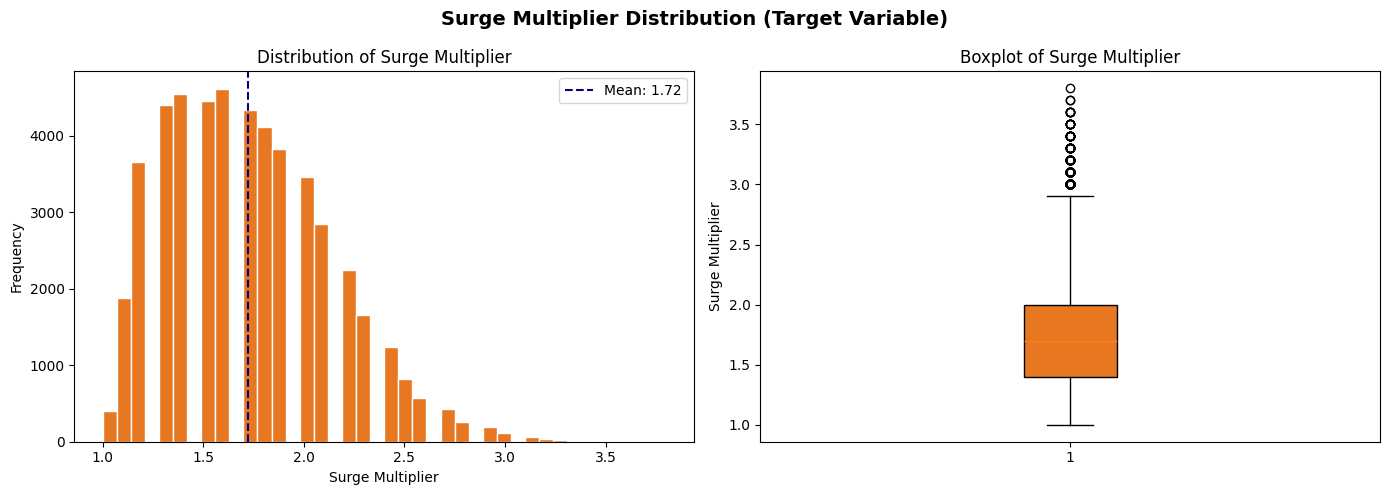


Surge Multiplier Stats:
count   50250.00
mean        1.72
std         0.41
min         1.00
25%         1.40
50%         1.70
75%         2.00
max         3.80
Name: surge_multiplier, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Surge Multiplier Distribution (Target Variable)", fontsize=14, fontweight="bold")

# Histogram
axes[0].hist(rides_df["surge_multiplier"].dropna(), bins=40, color="#E87722", edgecolor="white")
axes[0].set_title("Distribution of Surge Multiplier")
axes[0].set_xlabel("Surge Multiplier")
axes[0].set_ylabel("Frequency")
axes[0].axvline(rides_df["surge_multiplier"].mean(), color="navy", linestyle="--", label=f'Mean: {rides_df["surge_multiplier"].mean():.2f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(rides_df["surge_multiplier"].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#E87722", color="black"))
axes[1].set_title("Boxplot of Surge Multiplier")
axes[1].set_ylabel("Surge Multiplier")

plt.tight_layout()
plt.savefig("../data/raw/surge_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSurge Multiplier Stats:")
print(rides_df["surge_multiplier"].describe().round(2))

In [8]:
print("OUTLIER CHECK — Numerical Columns in Rides\n")

num_cols = ["distance_km", "duration_min", "fare_amount", "surge_multiplier"]

for col in num_cols:
    col_data = rides_df[col].dropna()
    print(f"  {col}")
    print(f"    min={col_data.min():.2f}  max={col_data.max():.2f}  "
          f"mean={col_data.mean():.2f}  "
          f"negative_values={( col_data < 0 ).sum()}")

OUTLIER CHECK — Numerical Columns in Rides

  distance_km
    min=-1.00  max=999.00  mean=9.33  negative_values=139
  duration_min
    min=-5.90  max=5988.50  mean=43.62  negative_values=221
  fare_amount
    min=13.20  max=70649.60  mean=334.30  negative_values=0
  surge_multiplier
    min=1.00  max=3.80  mean=1.72  negative_values=0


## Key Observations from Raw Data

### Nulls
- `fare_amount` has ~1.5% nulls — backend pricing service failures
- `pickup_zone` and `drop_zone` have ~2-3% nulls — GPS/app failures
- `driver_rating_given` has ~25%+ nulls — users who didn't rate
- `duration_min` is null for all cancelled/no_driver_found rides — expected

### Duplicates
- ~0.5% duplicate ride records — simulates system glitch double-writes
- ~1% duplicate users — same person registered twice

### Outliers
- `distance_km` has values of 0, -1, and 999 — corrupt GPS data
- `duration_min` has values of -5 and 500 — corrupt timestamps
- `age` in users has values like -1, 150, 999 — data entry errors

### Target Variable
- `surge_multiplier` ranges from 1.0 to 4.5
- Distribution is right-skewed — most rides are at 1.0–1.5x
- High surge (>3.0) happens but is rare — as expected in real life

### What This Means for Cleaning (Next Notebook)
- We cannot simply drop all nulls — too much data would be lost
- Outliers in distance/duration need domain-based capping not removal
- Duplicates need careful deduplication by ride_id not just row hash

In [9]:
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : len(df.columns),
        "null_cells" : df.isnull().sum().sum(),
        "duplicates" : df.duplicated().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n FINAL DATA SUMMARY\n")
print(summary_df.to_string(index=False))


 FINAL DATA SUMMARY

   table  rows  columns  null_cells  duplicates
   rides 50250       25       77988         250
 drivers  3000       16         998           0
   users 20200       13       14373         200
payments 39191        8       14866           0
 weather 87600        7        3473           0
